# Libraries

In [ ]:
import os
import time
import numpy as np
import pandas as pd
import faiss
import tarfile
import math
import seaborn as sns
import matplotlib.pyplot as plt

# Config

In [3]:
os.chdir("/app") # cd working directory 

# Datein und Pfade
tmp_dir = os.getcwd()
INPUT_PATH              = os.path.join(tmp_dir, "input")
SIFT_DATASET_PATH       = os.path.join(INPUT_PATH, "sift.tar.gz")
SIFT_DATASET_FILE_LIST  = ["sift_base.fvecs", "sift_query.fvecs", "sift_learn.fvecs"]

RESULTS_FOLDER_PATH     = os.path.join(tmp_dir, "output")
RESULTS_HNSW_PATH       = os.path.join(RESULTS_FOLDER_PATH, "benchmark_hnsw_params.csv")
RESULTS_INDEX_PATH      = os.path.join(RESULTS_FOLDER_PATH, "benchmark_index.csv")

# Parameter und Evaluation
K_PARAM_LIST            = [1,2,3] # Dont change range
SUBSET_SIZES_LIST       = [8000, 16000, 32000, 128000, 512000, 1000000] # Depends on dataset, SIFT = 1M Vectors
QUERY_TOP_K             = 5
RECALL_K                = QUERY_TOP_K - 4
NDCG_K                  = QUERY_TOP_K - 0

# REPRODUCIBLE RESULTS
RANDOM_STATE            = 42
QUERY_CONFIDENCE        = 0.95 # Choose: 0.9, 0.95, 0.99
QUERY_MARGIN_ERROR      = 0.05 

# Re-Run & Storing Results
RE_RUN_INDEX            = False #or use results instead
RE_RUN_HNSW_PARAMS      = False #or use results instead
SAVE_RESULTS            = False

# Scripts

## Data Collection

In [4]:
# Laden & Entpacken der .fvecs-Dateien
def load_and_extract():
    """
    Extrahiert alle .fvecs-Dateien aus SIFT_DATASET_PATH
    direkt in den Ordner INPUT_PATH (flach).
    """
    # Prüfen, ob bereits vorhanden
    if all(os.path.exists(os.path.join(INPUT_PATH, f)) for f in SIFT_DATASET_FILE_LIST):
        return
    # Flatten-entpacken
    with tarfile.open(SIFT_DATASET_PATH, "r:gz") as tar:
        for member in tar.getmembers():
            if member.isdir():
                continue
            filename = os.path.basename(member.name)
            if filename in SIFT_DATASET_FILE_LIST:
                source = tar.extractfile(member)
                if source is None:
                    continue
                target_path = os.path.join(INPUT_PATH, filename)
                with open(target_path, "wb") as out:
                    out.write(source.read())

# Reader für kleine .fvecs-Dateien (float32)
def read_fvecs(path):
    data = np.fromfile(path, dtype='int32')
    d = int(data[0])
    floats = data.reshape(-1, d+1)[:,1:].copy().view('float32')
    return floats

# Memmap für große Basis-Datei
def memmap_fvecs(path):
    arr = np.memmap(path, dtype='int32', mode='r')
    d = int(arr[0])
    n = arr.size // (d+1)
    arr = arr.reshape(n, d+1)
    return arr[:,1:].view('float32')  # memmap-backed

# Laden aller Daten
def load_data():
    """
    Extrahiert (falls nötig) und lädt alle Subsets.
    - xb: Basis-Daten als memmap
    - xq: Query-Daten als ndarray
    """
    load_and_extract()
    base_path  = os.path.join(INPUT_PATH, "sift_base.fvecs")
    query_path = os.path.join(INPUT_PATH, "sift_query.fvecs")
    xb = memmap_fvecs(base_path)
    xq = read_fvecs(query_path)
    return xb, xq

## Preprocessing

In [5]:
def normalize_vectors(x):
    """
    Inplace: Normiert jede Zeile von x auf Einheitslänge (L2)
    """
    norms = np.linalg.norm(x, axis=1, keepdims=True)
    # Vermeidet Division durch 0
    norms[norms == 0] = 1  
    x /= norms

def sample_size(population, confidence=0.95, margin_error=0.05, p=0.5):
    """
    Berechnet die nötige Stichprobengröße für ein binäres Merkmal bei endlicher Population.
    - population: Gesamtzahl (N)
    - confidence: Gewünschtes Konfidenzniveau (z.B. 0.95)
    - margin_error: Fehlerspanne (z.B. 0.05 für ±5%)
    - p: erwartete Trefferwahrscheinlichkeit (Default 0.5 für worst-case)
    """
    z_table = {0.90:1.645, 0.95:1.96, 0.99:2.576}
    Z = z_table.get(confidence, 1.96)
    n0 = (Z**2 * p * (1-p)) / (margin_error**2)
    n  = (population * n0) / (population + n0 - 1)
    return math.ceil(n)


## Indexing

In [6]:
# Baue Flat Index
def build_flat(xb):
    d = xb.shape[1]
    idx = faiss.IndexFlatIP(d) # due to L2 normalization it is equivalent to Cosine
    idx.add(xb)
    return idx

# Baue IVF Index
def build_ivf(xb_train, xb_add, nlist, nprobe):
    d = xb_add.shape[1]
    idx = faiss.index_factory(d, f"IVF{nlist},Flat")
    idx.nprobe = nprobe
    idx.train(xb_train)
    idx.add(xb_add)
    return idx

# Baue HNSW Index
def build_hnsw(xb, M, ef_construction, ef_search):
    d = xb.shape[1]
    idx = faiss.IndexHNSWFlat(d, M)
    idx.hnsw.efConstruction = ef_construction
    idx.hnsw.efSearch = ef_search
    idx.add(xb)
    return idx

## Evaluation Metrics

In [7]:
def recall_at_k(I_pred, I_gt, k):
    """
    Recall@k: Anteil der Queries, deren True-NN in den Top-k von I_pred ist.
    """
    hits = (I_pred[:, :k] == I_gt[:, [0]]).any(axis=1)
    return hits.mean()

def ndcg_at_k(I_pred, I_gt, k):
    """
    nDCG@k: Discounted Cumulative Gain normiert auf den idealen DCG.
    Relevanz ist 1, wenn die gesuchten NN reihenfolgegetreu unter den Top-k ist, sonst 0.
    """
    gains = np.isin(I_pred[:, :k], I_gt[:, :k]).astype(float)
    discounts = 1.0 / np.log2(np.arange(2, k+2))
    dcg = (gains * discounts).sum(axis=1)
    idcg = discounts.sum()
    return (dcg / idcg).mean()

def evaluate(index, xq, I_gt, search_k=5, recall_k=1, ndcg_k=5):
    """
    Führt eine Suche mit Top-search_k durch und gibt:
      - recall@recall_k
      - ndcg@ndcg_k
      - latency in ms
    zurück.
    """
    t0 = time.perf_counter()
    _, I = index.search(xq, search_k)
    latency = (time.perf_counter() - t0) * 1000
    return {
        f"recall@{recall_k}": recall_at_k(I, I_gt, recall_k),
        f"ndcg@{ndcg_k}":   ndcg_at_k(I, I_gt, ndcg_k),
        "latency_ms":       latency
    }

## Benchmarking

### All Indexes

In [8]:
def benchmark_subset(
    xb_full, xq_full,
    N,
    ks=K_PARAM_LIST,
    search_k=QUERY_TOP_K,
    recall_k=RECALL_K,
    ndcg_k=NDCG_K,
    query_confidence=QUERY_CONFIDENCE,
    margin_error=QUERY_MARGIN_ERROR,
    random_state=RANDOM_STATE
 ):
    """
    Führt Benchmark für N Basis-Vektoren und einer statistisch ausreichenden Stichprobe von Queries durch.
    - query_confidence: Konfidenzniveau (z.B. 0.95)
    - margin_error: zulässige Fehlerspanne (z.B. 0.05)
    """
    rng = np.random.default_rng(random_state)
    # 1) Subsample der Basis-Vektoren
    idxs = rng.choice(xb_full.shape[0], N, replace=False)
    xb = xb_full[idxs]
    normalize_vectors(xb)

    # 2) Statistische Stichprobe der Queries
    total_q = xq_full.shape[0]
    n_q = sample_size(total_q, confidence=query_confidence, margin_error=margin_error)
    q_idxs = rng.choice(total_q, n_q, replace=False)
    xq = xq_full[q_idxs]

    # 3) Flat-Index & Ground-Truth
    flat_idx = build_flat(xb)
    _, I_gt = flat_idx.search(xq, search_k)
    print(f"Ground-Truth abgeschlossen")

    rows = []
    # Flat baseline
    rows.append({"N":N, "Q":n_q, "algo":"Flat", **evaluate(flat_idx, xq, I_gt, search_k, recall_k, ndcg_k)})

    # IVF-Varianten
    sqrtN = int(np.sqrt(N))
    for k in ks:
        nlist  = sqrtN * (2**k)
        nprobe = 2**(k)
        ivf_idx = build_ivf(xb, xb, nlist, nprobe)
        rows.append({"N":N, "Q":n_q, "algo":"IVF", "k":k,
                     "nlist":nlist, "nprobe":nprobe,
                     **evaluate(ivf_idx, xq, I_gt, search_k, recall_k, ndcg_k)})
        print(f"IVF: {k=}, {nlist=}, {nprobe=}")

    # HNSW-Varianten
    for k in ks:
        M = 4**k
        efC = 4**k
        efS = 4**k
        hnsw_idx = build_hnsw(xb, M, efC, efS)
        rows.append({"N":N, "Q":n_q, "algo":"HNSW", "k":k,
                     "M":M, "efConstruction":efC, "efSearch":efS,
                     **evaluate(hnsw_idx, xq, I_gt, search_k, recall_k, ndcg_k)})
        print(f"HNSW: {k=}, {M=}, {efC=}, {efS=}")

    return rows

In [9]:
def run_benchmark(subset_sizes=SUBSET_SIZES_LIST):
    xb_full, xq_full = load_data()
    normalize_vectors(xq_full)  # nur einmal
    all_rows = []
    for N in subset_sizes:
        try:
            rows = benchmark_subset(
                xb_full, xq_full, N,
                ks=K_PARAM_LIST,
                search_k=QUERY_TOP_K,
                recall_k=RECALL_K,
                ndcg_k=NDCG_K,
                query_confidence=QUERY_CONFIDENCE,
                margin_error=QUERY_MARGIN_ERROR,
                random_state=RANDOM_STATE
            )
        except MemoryError:
            print(f"MemoryError: {N} zu groß")
            continue
        except Exception as e:
            print(f"Fehler bei N={N}: {e}")
            continue

        all_rows += rows
        print(f"Benchmark für {N} Vektoren abgeschlossen.")

    return pd.DataFrame(all_rows)

### HNSW Parameter

In [ ]:
def hnsw_benchmark_subset(
    xb_full, xq_full,
    N,
    ks=K_PARAM_LIST,
    search_k=QUERY_TOP_K,
    recall_k=RECALL_K,
    ndcg_k=NDCG_K,
    query_confidence=QUERY_CONFIDENCE,
    margin_error=QUERY_MARGIN_ERROR,
    random_state=RANDOM_STATE
):
    """
    Benchmarkt nur HNSW-Varianten.
    Gibt eine Liste von Ergebnis-Dicts zurück.
    """
    # 0) Validierung
    assert ks, "K_PARAM_LIST darf nicht leer sein!"
    assert 0 < N <= xb_full.shape[0], f"N muss in (0, {xb_full.shape[0]}] liegen"

    rng = np.random.default_rng(random_state)

    # 1) Basis-Subsample
    idxs = rng.choice(xb_full.shape[0], N, replace=False)
    xb = xb_full[idxs]
    normalize_vectors(xb)

    # 2) Query-Stichprobe
    total_q = xq_full.shape[0]
    n_q = sample_size(total_q, confidence=query_confidence, margin_error=margin_error)
    if n_q <= 0:
        raise ValueError(f"Keine Queries (n_q={n_q}) – prüfe Confidence/Margin-Parameter")
    q_idxs = rng.choice(total_q, n_q, replace=False)
    xq = xq_full[q_idxs]
    normalize_vectors(xq)

    # 3) Ground-Truth
    flat_idx = build_flat(xb)
    _, I_gt = flat_idx.search(xq, search_k)

    rows = []
    start = time.perf_counter()

    # 4) HNSW-Parametergrid
    for k_M in ks:
        M = 4 ** k_M
        for k_C in range(2, 5):
            efC = 4 ** k_C
            for k_S in range(0, 9):
                efS = 2 ** k_S
                try:
                    hnsw_idx = build_hnsw(xb, M, efC, efS)
                    stats    = evaluate(hnsw_idx, xq, I_gt, search_k, recall_k, ndcg_k)
                    rows.append({
                        "N": N,
                        "Q": n_q,
                        "algo": "HNSW",
                        "M": M,
                        "efConstruction": efC,
                        "efSearch": efS,
                        **stats
                    })
                    elapsed = time.perf_counter() - start
                    print(f"{elapsed:.2f}s – N={N}, M={M}, efC={efC}, efS={efS} ✓")
                except Exception as e:
                    print(f"⚠️ Fehler N={N}, M={M}, efC={efC}, efS={efS}: {e}")
        
    print(f"[INFO] Für N={N} gesammelte Einträge: {len(rows)}")
    return rows


def hnsw_run_benchmark(
    subset_sizes=SUBSET_SIZES_LIST,
    xb_full=None, xq_full=None,
    ks=K_PARAM_LIST,
    search_k=QUERY_TOP_K,
    recall_k=RECALL_K,
    ndcg_k=NDCG_K,
    query_confidence=QUERY_CONFIDENCE,
    margin_error=QUERY_MARGIN_ERROR,
    random_state=RANDOM_STATE
):
    """
    Ruft hnsw_benchmark_subset für jede Größe auf,
    sammelt alle Dict-Ergebnisse und gibt ein DataFrame zurück.
    """
    # Daten laden, falls nicht übergeben
    if xb_full is None or xq_full is None:
        xb_full, xq_full = load_data()
        normalize_vectors(xq_full)

    all_rows = []

    for N in subset_sizes:
        try:
            rows = hnsw_benchmark_subset(
                xb_full, xq_full, N,
                ks=ks,
                search_k=search_k,
                recall_k=recall_k,
                ndcg_k=ndcg_k,
                query_confidence=query_confidence,
                margin_error=margin_error,
                random_state=random_state
            )
        except MemoryError:
            print(f"⚠️ MemoryError: N={N} zu groß, übersprungen.")
            continue
        except Exception as e:
            print(f"❌ Unerwarteter Fehler bei N={N}: {e}")
            continue

        if not rows:
            print(f"⚠️ Keine Ergebnisse für N={N}, übersprungen.")
            continue

        all_rows.extend(rows)
        print(f"✅ Benchmark für N={N} abgeschlossen ({len(rows)} Einträge).")

    result_df = pd.DataFrame(all_rows)
    print(f"\n[RESULT] Gesamtzeilen im Ergebnis-DataFrame: {len(result_df)}")
    return result_df

In [11]:
def hnsw_run_benchmark(subset_sizes=SUBSET_SIZES_LIST):
    xb_full, xq_full = load_data()
    normalize_vectors(xq_full)  # nur einmal
    all_rows = []
    for N in subset_sizes:
        try:
            rows = hnsw_benchmark_subset(
                xb_full, xq_full, N,
                ks=K_PARAM_LIST,
                search_k=QUERY_TOP_K,
                recall_k=RECALL_K,
                ndcg_k=NDCG_K,
                query_confidence=QUERY_CONFIDENCE,
                margin_error=QUERY_MARGIN_ERROR,
                random_state=RANDOM_STATE
            )
        except MemoryError:
            print(f"MemoryError: {N} zu groß")
            continue
        except Exception as e:
            print(f"Fehler bei N={N}: {e}")
            continue

        all_rows += rows
        print(f"Benchmark für {N} Vektoren abgeschlossen.")

    return pd.DataFrame(all_rows)

## Visualisation

In [12]:
def plot_line_groups(
    df,
    x: str,
    y: str,
    hue: str = None,
    style: str = None,
    palette: str = "Set2",
    title: str = None,
    xlabel: str = None,
    ylabel: str = None,
    figsize: tuple = (10, 6),
    marker: bool = True,
    dashes: bool = False,
    xlim: tuple = None,
    ylim: tuple = None,
    save_path: str = None
):
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=figsize)

    ax = sns.lineplot(
        data=df,
        x=x, y=y,
        hue=hue,
        style=style,
        palette=palette,
        markers=marker,
        dashes=dashes,
        linewidth=2.0,
        alpha=0.85,
    )

    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)

    ax.set_title(title or f"{y} vs {x}", fontsize=16, pad=12)
    ax.set_xlabel(xlabel or x, fontsize=14)
    ax.set_ylabel(ylabel or y, fontsize=14)
    ax.tick_params(labelsize=12)

    if hue:
        leg = ax.legend(title=hue, title_fontsize=12, fontsize=11, loc="best", frameon=True)
        leg.get_frame().set_edgecolor("gray")
        leg.get_frame().set_alpha(0.9)

    plt.tight_layout()

    if save_path:
        fig = ax.get_figure()
        fig.savefig(save_path, bbox_inches="tight")

    return ax


def plot_scatter_groups(
    df,
    x: str,
    y: str,
    hue: str = None,
    style: str = None,
    size: str = None,
    palette: str = "Dark2",
    markers: bool = True,
    size_range: tuple = (40, 200),
    alpha: float = 0.7,
    edgecolor: str = "w",
    linewidth: float = 0.5,
    title: str = None,
    xlabel: str = None,
    ylabel: str = None,
    figsize: tuple = (10, 6),
    xlim: tuple = None,
    ylim: tuple = None,
    save_path: str = None
):
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=figsize)

    ax = sns.scatterplot(
        data=df,
        x=x, y=y,
        hue=hue,
        style=style if markers else None,
        size=size,
        palette=palette,
        sizes=size_range,
        alpha=alpha,
        edgecolor=edgecolor,
        linewidth=linewidth,
    )

    if xlim is not None:
        ax.set_xlim(xlim)
    if ylim is not None:
        ax.set_ylim(ylim)

    ax.set_title(title or f"{y} vs {x}", fontsize=16, pad=12)
    ax.set_xlabel(xlabel or x, fontsize=14)
    ax.set_ylabel(ylabel or y, fontsize=14)
    ax.tick_params(labelsize=12)

    if hue or style or size:
        leg = ax.legend(title=hue or style or size, title_fontsize=12, fontsize=11, loc="best", frameon=True)
        leg.get_frame().set_edgecolor("gray")
        leg.get_frame().set_alpha(0.9)

    plt.tight_layout()

    if save_path:
        fig = ax.get_figure()
        fig.savefig(save_path, bbox_inches="tight")

    return ax

# Experiment

## All Indexes over N

In [13]:
if RE_RUN_INDEX:
    df_results = run_benchmark(SUBSET_SIZES_LIST)
    if SAVE_RESULTS:
            df_results.to_csv(RESULTS_INDEX_PATH, index=False)
            print(f"Ergebnisse gespeichert: {RESULTS_INDEX_PATH}")
else: 
    try:
        df_results = pd.read_csv(RESULTS_INDEX_PATH)
        print(f"Ergebnisse geladen: {RESULTS_INDEX_PATH}")
    except FileNotFoundError:
        print(f"Datei nicht gefunden: {RESULTS_INDEX_PATH}")

Ergebnisse geladen: /app/output/benchmark_index.csv


In [14]:
df_results.sort_values(by=["algo", "N",  "k"], inplace=True)
df_results

,N,Q,algo,recall@1,ndcg@5,latency_ms,k,nlist,nprobe,M,efConstruction,efSearch,ms_per_query
0,8000,370,Flat,1.000000,1.000000,8.138292,NaN,NaN,NaN,NaN,NaN,NaN,0.021995
7,16000,370,Flat,1.000000,1.000000,14.980959,NaN,NaN,NaN,NaN,NaN,NaN,0.040489
14,32000,370,Flat,1.000000,1.000000,31.928042,NaN,NaN,NaN,NaN,NaN,NaN,0.086292
21,128000,370,Flat,1.000000,1.000000,126.089542,NaN,NaN,NaN,NaN,NaN,NaN,0.340783
28,512000,370,Flat,1.000000,1.000000,506.875917,NaN,NaN,NaN,NaN,NaN,NaN,1.369935
35,1000000,370,Flat,1.000000,1.000000,988.428626,NaN,NaN,NaN,NaN,NaN,NaN,2.671429
4,8000,370,HNSW,0.289189,0.539318,0.628500,1.0,NaN,NaN,4.0,4.0,4.0,0.001699
5,8000,370,HNSW,0.970270,0.966296,2.699834,2.0,NaN,NaN,16.0,16.0,16.0,0.007297
6,8000,370,HNSW,1.000000,1.000000,15.290792,3.0,NaN,NaN,64.0,64.0,64.0,0.041326
11,16000,370,HNSW,0.229730,0.379618,0.824208,1.0,NaN,NaN,4.0,4.0,4.0,0.002228


## HNSW Parameter

In [15]:
if RE_RUN_HNSW_PARAMS:
    df_hnsw_results = hnsw_run_benchmark([512000])
    if SAVE_RESULTS:
        df_hnsw_results.to_csv(RESULTS_HNSW_PATH, index=False)
        print(f"Ergebnisse gespeichert: {RESULTS_HNSW_PATH}")
else:
    try:
        df_hnsw_results = pd.read_csv(RESULTS_HNSW_PATH)
        print(f"Ergebnisse geladen: {RESULTS_HNSW_PATH}")
    except FileNotFoundError:
        print(f"Datei nicht gefunden: {RESULTS_HNSW_PATH}")

Ergebnisse geladen: /app/output/benchmark_hnsw_params.csv


In [16]:
df_hnsw_results['ms_per_query'] = df_hnsw_results['latency_ms'] / df_hnsw_results['Q']
df_hnsw_results.to_csv(RESULTS_HNSW_PATH, index=False)
df_hnsw_results

,N,Q,algo,M,efConstruction,efSearch,recall@1,ndcg@5,latency_ms,ms_per_query
0,512000,370,HNSW,4,16,1,0.118919,0.119181,1.808208,0.004887
1,512000,370,HNSW,4,16,2,0.172973,0.169924,1.872750,0.005061
2,512000,370,HNSW,4,16,4,0.235135,0.243412,2.635375,0.007123
3,512000,370,HNSW,4,16,8,0.329730,0.347735,3.932458,0.010628
4,512000,370,HNSW,4,16,16,0.424324,0.458746,6.814417,0.018417
...,...,...,...,...,...,...,...,...,...,...
76,512000,370,HNSW,64,256,16,0.943243,0.946203,20.983667,0.056713
77,512000,370,HNSW,64,256,32,0.978378,0.983504,34.312125,0.092735
78,512000,370,HNSW,64,256,64,0.994595,0.997518,58.842708,0.159034
79,512000,370,HNSW,64,256,128,0.994595,0.998582,108.009666,0.291918


# Analysis

In [17]:
df_results.columns

Index(['N', 'Q', 'algo', 'recall@1', 'ndcg@5', 'latency_ms', 'k', 'nlist',
       'nprobe', 'M', 'efConstruction', 'efSearch', 'ms_per_query'],
      dtype='object')

### Exploration: All Indexes
#### Precision vs. N

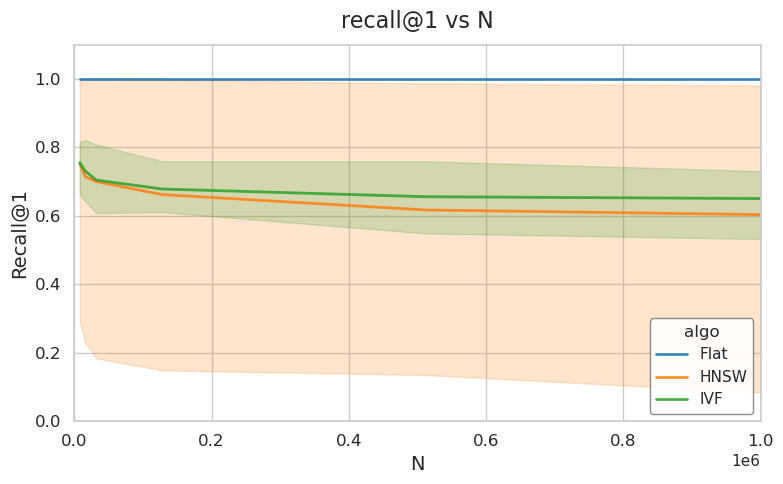

In [18]:
df = df_results.copy()

x = "N"
y = "recall@1"
ax = plot_line_groups(
    df,
    x=x,
    y=y,
    hue="algo",
    style=None,
    palette="tab10",
    title="",
    xlabel=x,
    ylabel="Recall@1",
    figsize=(8,5),
    ylim=(0, 1.1),
    xlim=(0, 1000000),
    save_path=os.path.join(RESULTS_FOLDER_PATH, "recall1_indexes.png")  
)

#### Speed vs. N

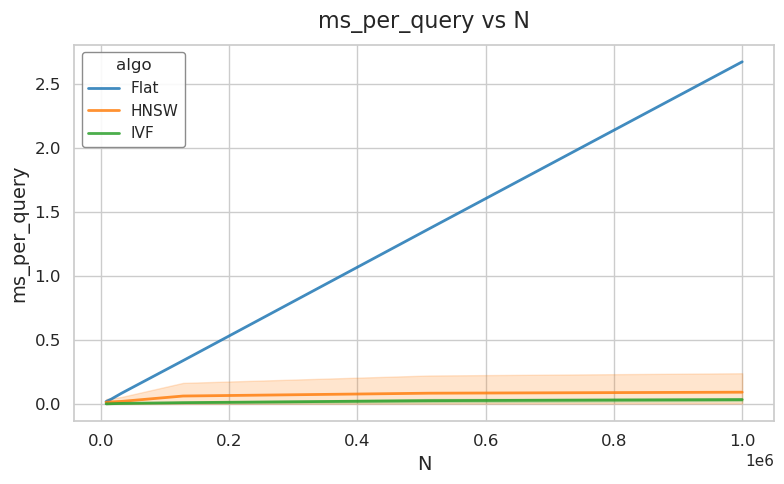

In [19]:
df = df_results.copy()

x = "N"
y = "ms_per_query" 
ax = plot_line_groups(
    df,
    x=x,
    y=y,
    hue="algo",
    style=None,
    palette="tab10",
    title="",
    xlabel=x,
    ylabel=y,
    figsize=(8,5),
    save_path=os.path.join(RESULTS_FOLDER_PATH, "_latency_indexes.png")
)

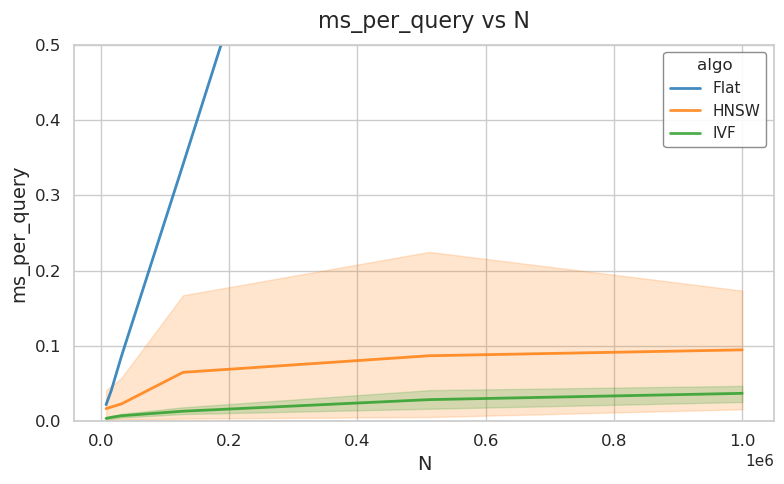

In [20]:
df = df_results.copy()

x = "N"
y = "ms_per_query" 
ax = plot_line_groups(
    df,
    x=x,
    y=y,
    hue="algo",
    style=None,
    palette="tab10",
    title="",
    xlabel=x,
    ylabel=y,
    figsize=(8,5),
    ylim=(0, 0.5),
    save_path=os.path.join(RESULTS_FOLDER_PATH, "_latency_index_zoomed.png")
)

#### Precision vs. Latency

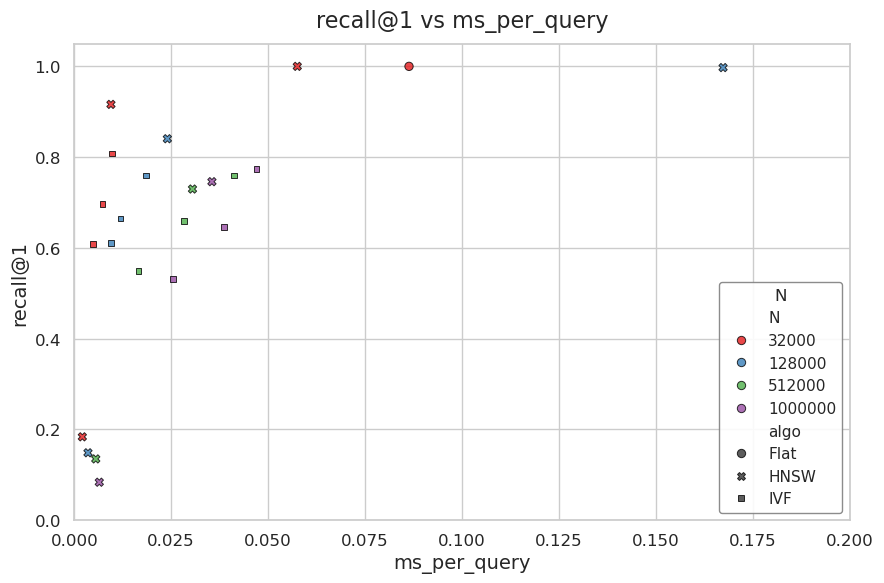

In [21]:
# Angenommen df_results enthält deine Benchmark-Daten
df = df_results[df_results["N"] >= 32000].copy()

x = "ms_per_query"
y = "recall@1"
ax = plot_scatter_groups(
    df,
    x=x,
    y=y,
    hue="N",
    style="algo",
    size=None,
    palette="Set1",
    markers=True,
    size_range=(50, 300),
    alpha=0.8,
    edgecolor="black",
    linewidth=0.7,
    title="",
    xlabel=x,
    ylabel=y,
    xlim=(0,.2),
    ylim=(0, 1.05),
    figsize=(9,6),
    save_path=os.path.join(RESULTS_FOLDER_PATH, "_recall1_latencies_index.png")
)

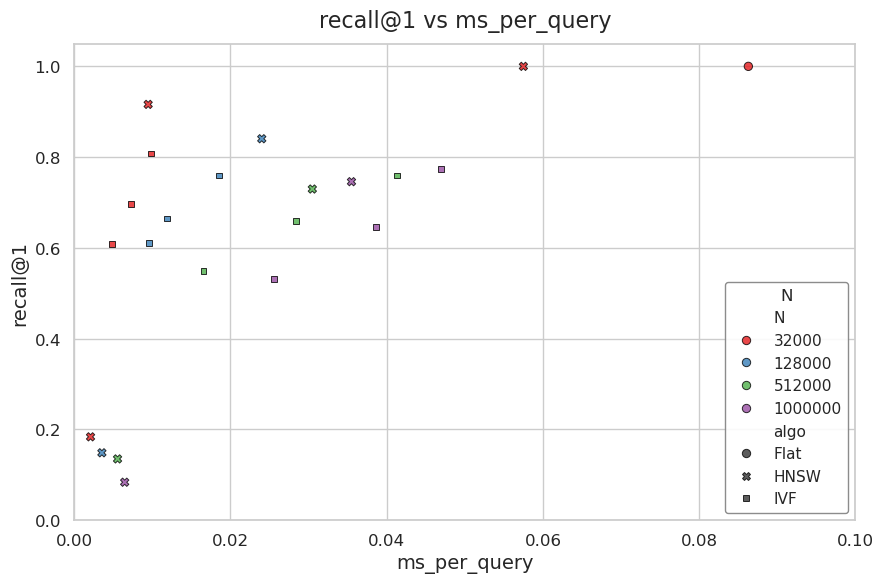

In [22]:
# Angenommen df_results enthält deine Benchmark-Daten
df = df_results[df_results["N"] >= 32000].copy()

x = "ms_per_query"
y = "recall@1"
ax = plot_scatter_groups(
    df,
    x=x,
    y=y,
    hue="N",
    style="algo",
    size=None,
    palette="Set1",
    markers=True,
    size_range=(50, 300),
    alpha=0.8,
    edgecolor="black",
    linewidth=0.7,
    title="",
    xlabel=x,
    ylabel=y,
    xlim=(0,.1),
    ylim=(0, 1.05),
    figsize=(9,6),
    save_path=os.path.join(RESULTS_FOLDER_PATH, "_recall1_latencies_index_zoomed.png")
)

#### Other

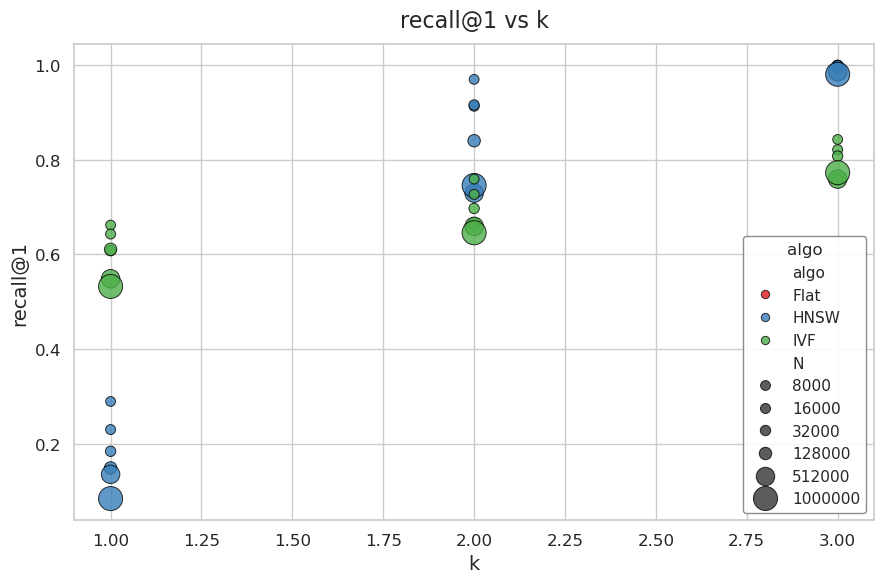

In [23]:
# Angenommen df_results enthält deine Benchmark-Daten
x = "k"
y = "recall@1"
ax = plot_scatter_groups(
    df_results,
    x=x,
    y=y,
    hue="algo",
    style=None,
    size="N",
    palette="Set1",
    markers=True,
    size_range=(50, 300),
    alpha=0.8,
    edgecolor="black",
    linewidth=0.7,
    title="",
    xlabel=x,
    ylabel=y,
    #xlim=(0, 25),
    #ylim=(0.5, 1.1),
    figsize=(9,6)
)

### Exploration: HNSW Params

In [24]:
print(df_hnsw_results.columns)

df_hnsw_results.head(3)

Index(['N', 'Q', 'algo', 'M', 'efConstruction', 'efSearch', 'recall@1',
       'ndcg@5', 'latency_ms', 'ms_per_query'],
      dtype='object')


,N,Q,algo,M,efConstruction,efSearch,recall@1,ndcg@5,latency_ms,ms_per_query
0,512000,370,HNSW,4,16,1,0.118919,0.119181,1.808208,0.004887
1,512000,370,HNSW,4,16,2,0.172973,0.169924,1.872750,0.005061
2,512000,370,HNSW,4,16,4,0.235135,0.243412,2.635375,0.007123


#### Precision & Latency by params

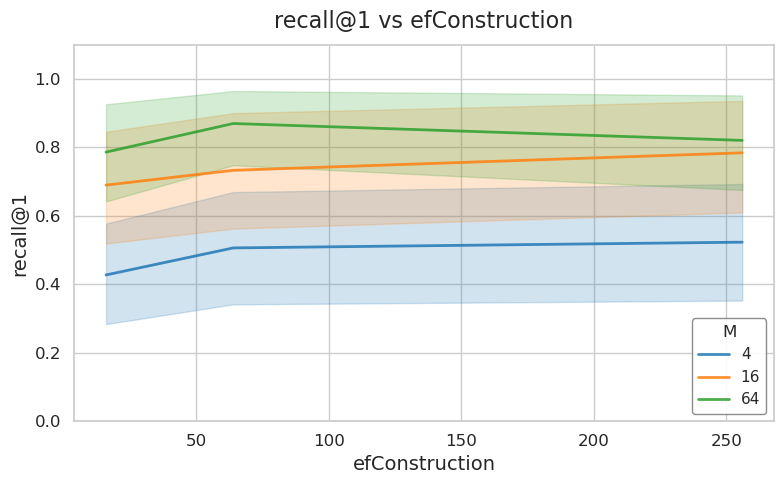

In [25]:
df_hnsw = df_hnsw_results.copy()

x = "efConstruction"
y = "recall@1" 
group = "M"
group_2 = None
ax = plot_line_groups(
    df_hnsw,
    x=x,
    y=y,
    hue=group,
    style=group_2,
    palette="tab10",
    title="",
    xlabel=x,
    ylabel=y,
    figsize=(8,5),
    ylim=(0, 1.1)
    #xlim=(0, 1000000),
)

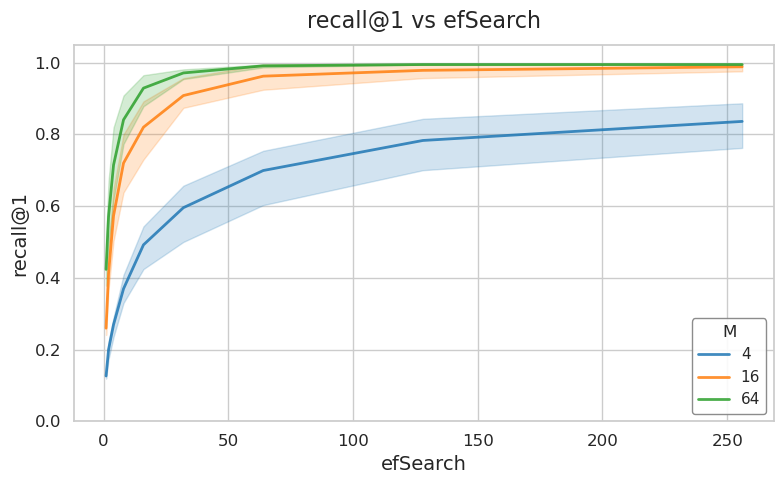

In [26]:
df_hnsw = df_hnsw_results.copy()

x = "efSearch"
y = "recall@1"
group = "M"
group_2 = None
ax = plot_line_groups(
    df_hnsw,
    x=x,
    y=y,
    hue=group,
    style=group_2,
    palette="tab10",
    title="",
    xlabel=x,
    ylabel=y,
    figsize=(8,5),
    ylim=(0, 1.05),
    #xlim=(0, 1000000),
    save_path=os.path.join(RESULTS_FOLDER_PATH, "_hnsw_recall1_efsearch.png")
)

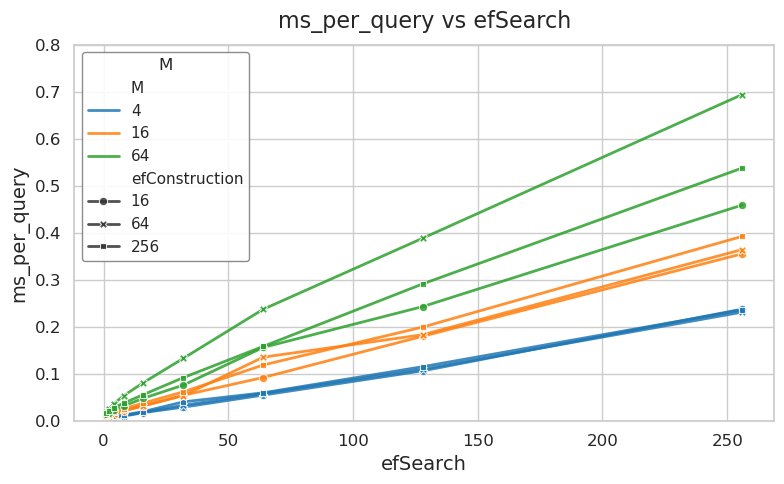

In [27]:
df_hnsw = df_hnsw_results.copy()

x = "efSearch"
y = "ms_per_query"
group = "M"
group_2 = "efConstruction"
ax = plot_line_groups(
    df_hnsw,
    x=x,
    y=y,
    hue=group,
    style=group_2,
    palette="tab10",
    title="",
    xlabel=x,
    ylabel=y,
    figsize=(8,5),
    ylim=(0, 0.8),
    #xlim=(0, 1000000),
)

#### Precision vs. Latency

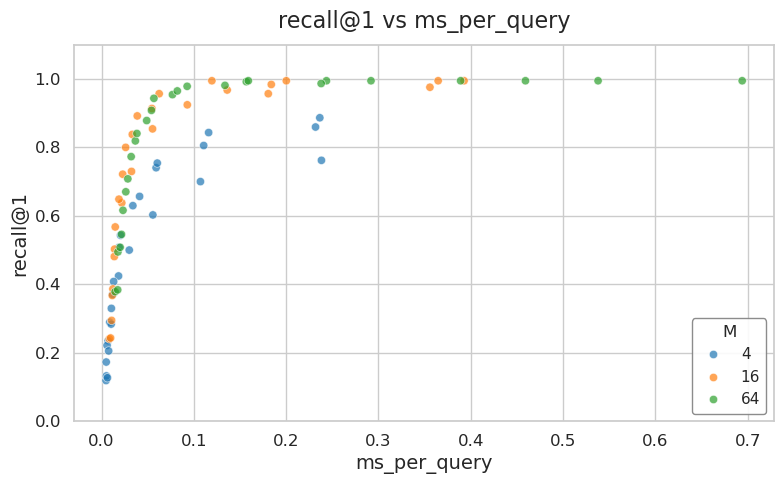

In [28]:
df_hnsw = df_hnsw_results.copy()

x = "ms_per_query"
y = "recall@1" 
group = "M"
group_2 = None
ax = plot_scatter_groups(
    df_hnsw,
    x=x,
    y=y,
    hue=group,
    style=group_2,
    palette="tab10",
    title="",
    xlabel=x,
    ylabel=y,
    figsize=(8,5),
    ylim=(0, 1.1)
    #xlim=(0, 1000000),
)

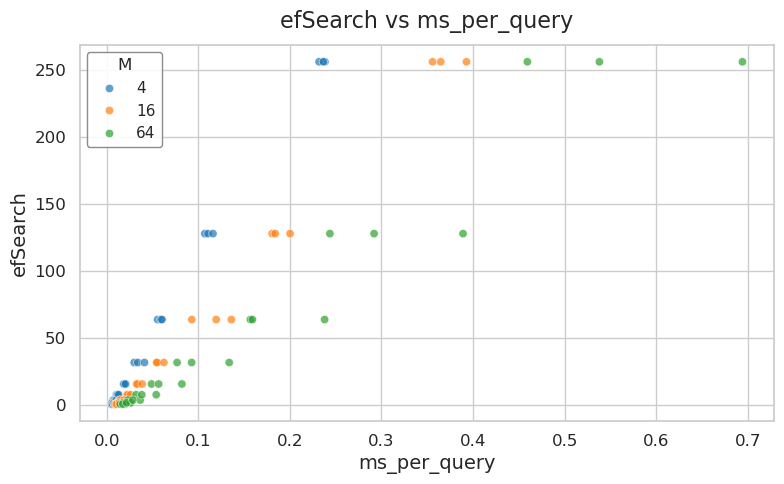

In [29]:
df_hnsw = df_hnsw_results.copy()

x = "ms_per_query"
y = "efSearch" 
group = "M"
group_2 = None
ax = plot_scatter_groups(
    df_hnsw,
    x=x,
    y=y,
    hue=group,
    style=group_2,
    palette="tab10",
    title="",
    xlabel=x,
    ylabel=y,
    figsize=(8,5),
    #ylim=(0, 1.1)
    #xlim=(0, 1000000),
)

### Hypothesis
#### Datensatz: All Index

% All Index

A) N:
- H1: NNS (FlatIndex) O(n) complexity vs. ANNS O(log(n)) complexity
- H2: ANNS: No relation between recall@1 and N with constant parameters

B) Latency vs. Precision:
- ANNS: Positive relation between recall@1 and ms_per_query

% HNSW
- HNSW: Logarithmic against Recall@1

C) HNSW:
- Positive relation between M and recall@1
- Positive relation between M and  ms_per_query
- Positive relation between ef_search and recall@1 
- Positive relation between ef_search and ms_per_query

A-H1 | Flat: corr(ms_per_query, N) = 1.00
A-H1 | Flat: corr(ms_per_query, log(N)) = 0.89
A-H2 | ANNS: corr(recall@1, N) = -0.14
B-H1 | ANNS: corr(recall@1, ms_per_query) = 0.45


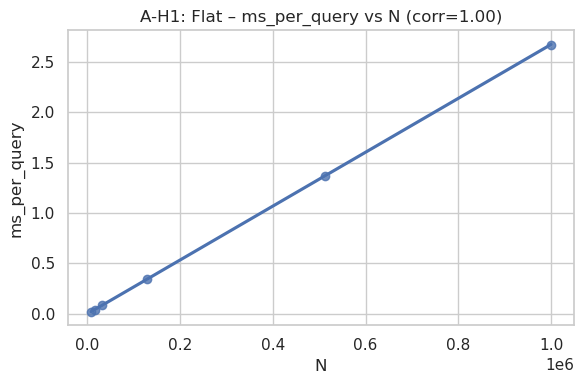

Gespeichert: /app/output/A-H1_linear.png


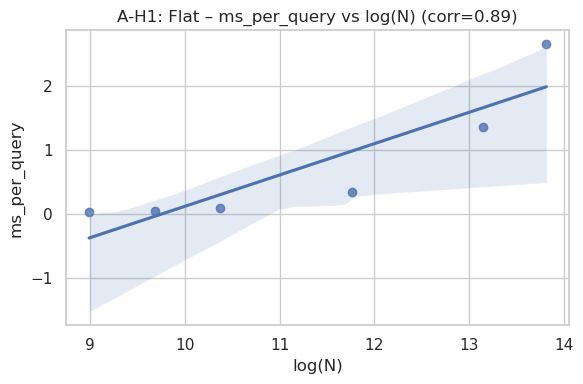

Gespeichert: /app/output/A-H1_log.png


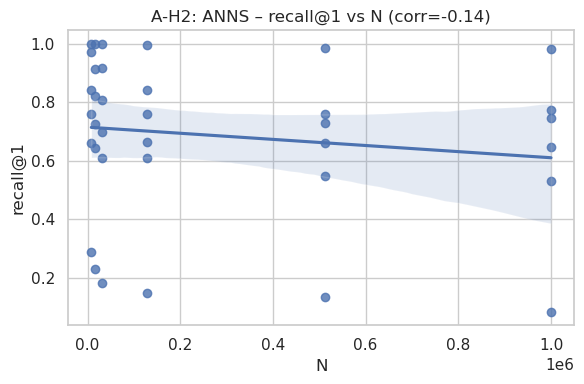

Gespeichert: /app/output/A-H2_recall_vs_N.png


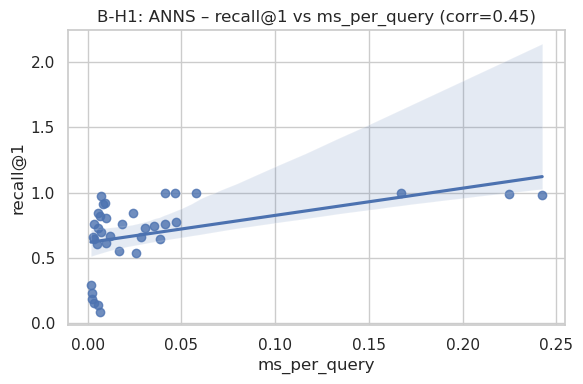

Gespeichert: /app/output/B-H1_recall_vs_latency.png


In [30]:
# --- Daten vorbereiten ---
df = df_results.copy()
relevant_cols = ['N', 'recall@1', 'latency_ms', 'ms_per_query']
df[relevant_cols] = df[relevant_cols].apply(pd.to_numeric)

flat = df[df['algo'] == 'Flat']
anns = df[df['algo'] != 'Flat']

# --- 1) Ergebnisse der Hypothesen berechnen und printen ---
# A-H1: Flat – ms_per_query vs N / log(N)
corr_linear = flat['ms_per_query'].corr(flat['N'])
corr_log = flat['ms_per_query'].corr(np.log(flat['N']))
print(f"A-H1 | Flat: corr(ms_per_query, N) = {corr_linear:.2f}")
print(f"A-H1 | Flat: corr(ms_per_query, log(N)) = {corr_log:.2f}")

# A-H2: ANNS – recall@1 vs N
corr_recall_n = anns['recall@1'].corr(anns['N'])
print(f"A-H2 | ANNS: corr(recall@1, N) = {corr_recall_n:.2f}")

# B-H1: ANNS – recall@1 vs ms_per_query
corr_anns = anns['recall@1'].corr(anns['ms_per_query'])
print(f"B-H1 | ANNS: corr(recall@1, ms_per_query) = {corr_anns:.2f}")


# --- 2) Visualisierungen mit Speichern ---
def save_plot(fig_name):
    path = os.path.join(RESULTS_FOLDER_PATH, f"{fig_name}.png")
    plt.tight_layout()
    plt.savefig(path)
    plt.show()
    print(f"Gespeichert: {path}")

# A-H1 linear
plt.figure(figsize=(6,4))
sns.regplot(x='N', y='ms_per_query', data=flat)
plt.title(f"A-H1: Flat – ms_per_query vs N (corr={corr_linear:.2f})")
plt.xlabel("N")
plt.ylabel("ms_per_query")
save_plot("A-H1_linear")

# A-H1 logarithmisch
plt.figure(figsize=(6,4))
sns.regplot(x=np.log(flat['N']), y=flat['ms_per_query'])
plt.title(f"A-H1: Flat – ms_per_query vs log(N) (corr={corr_log:.2f})")
plt.xlabel("log(N)")
plt.ylabel("ms_per_query")
save_plot("A-H1_log")

# A-H2 Recall vs N
plt.figure(figsize=(6,4))
sns.regplot(x='N', y='recall@1', data=anns)
plt.title(f"A-H2: ANNS – recall@1 vs N (corr={corr_recall_n:.2f})")
plt.xlabel("N")
plt.ylabel("recall@1")
save_plot("A-H2_recall_vs_N")

# B-H1 Recall vs ms_per_query
plt.figure(figsize=(6,4))
sns.regplot(x='ms_per_query', y='recall@1', data=anns)
plt.title(f"B-H1: ANNS – recall@1 vs ms_per_query (corr={corr_anns:.2f})")
plt.xlabel("ms_per_query")
plt.ylabel("recall@1")
save_plot("B-H1_recall_vs_latency")

#### Datensatz: HNSW

B-H2 | HNSW: corr(recall@1, log(ms_per_query)) = 0.90
C-H1 | HNSW: corr(recall@1, log(M)) = 0.50
C-H2 | HNSW: corr(ms_per_query, log(M)) = 0.28
C-H3 | HNSW: corr(recall@1, log(efSearch)) = 0.80
C-H4 | HNSW: corr(ms_per_query, efSearch) = 0.89


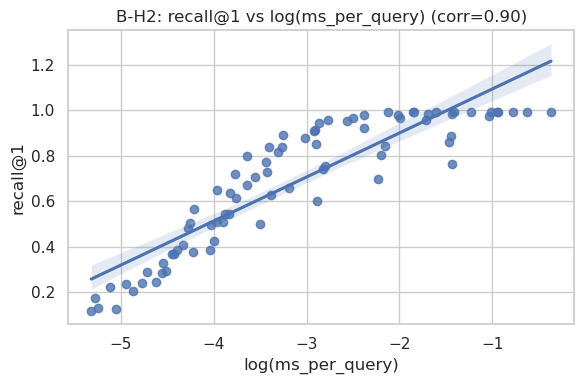

<Figure size 640x480 with 0 Axes>

Gespeichert: /app/output/B-H2_recall_vs_log_latency.png


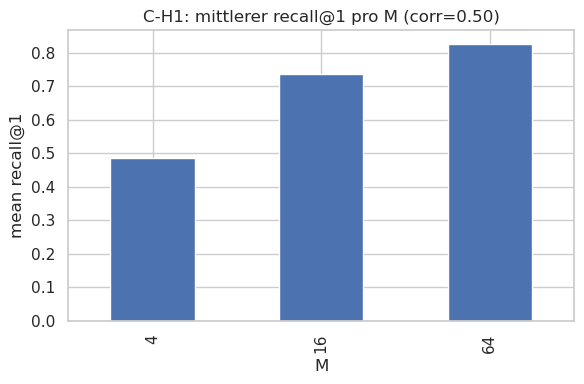

<Figure size 640x480 with 0 Axes>

Gespeichert: /app/output/C-H1_mean_recall_per_M.png


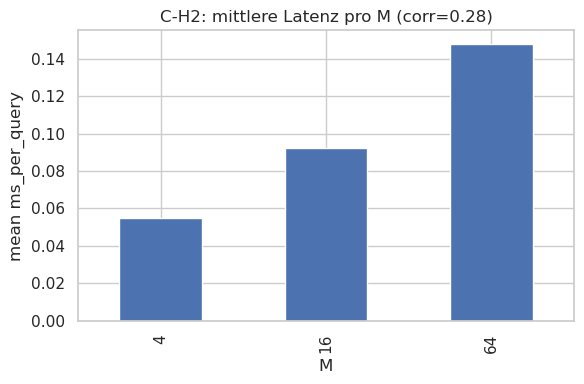

<Figure size 640x480 with 0 Axes>

Gespeichert: /app/output/C-H2_mean_latency_per_M.png


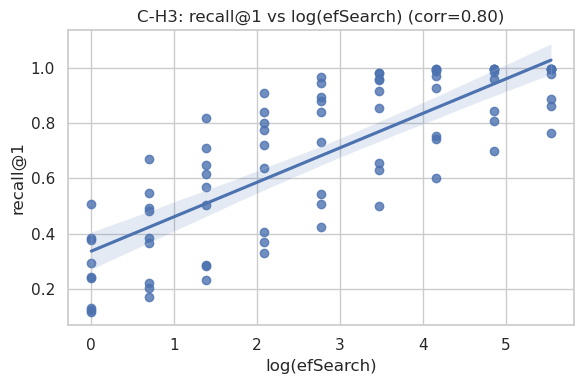

<Figure size 640x480 with 0 Axes>

Gespeichert: /app/output/C-H3_recall_vs_log_efSearch.png


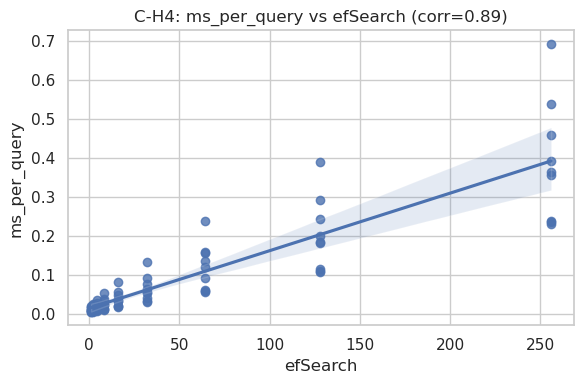

<Figure size 640x480 with 0 Axes>

Gespeichert: /app/output/C-H4_latency_vs_efSearch.png


In [31]:
# --- Daten vorbereiten ---
hnsw_df = df_hnsw_results.copy()
cols = ['M', 'efSearch', 'recall@1', 'ms_per_query']
hnsw_df[cols] = hnsw_df[cols].apply(pd.to_numeric)

# --- 1) Ergebnisse der Hypothesen berechnen und printen ---
# B-H2
corr_bh2 = hnsw_df['recall@1'].corr(np.log(hnsw_df['ms_per_query']))
print(f"B-H2 | HNSW: corr(recall@1, log(ms_per_query)) = {corr_bh2:.2f}")

# C-H1
corr_ch1 = hnsw_df['recall@1'].corr(np.log(hnsw_df['M']))
print(f"C-H1 | HNSW: corr(recall@1, log(M)) = {corr_ch1:.2f}")

# C-H2
corr_ch2 = hnsw_df['ms_per_query'].corr(np.log(hnsw_df['M']))
print(f"C-H2 | HNSW: corr(ms_per_query, log(M)) = {corr_ch2:.2f}")

# C-H3
corr_ch3 = hnsw_df['recall@1'].corr(np.log(hnsw_df['efSearch']))
print(f"C-H3 | HNSW: corr(recall@1, log(efSearch)) = {corr_ch3:.2f}")

# C-H4
corr_ch4 = hnsw_df['ms_per_query'].corr(hnsw_df['efSearch'])
print(f"C-H4 | HNSW: corr(ms_per_query, efSearch) = {corr_ch4:.2f}")


# --- 2) Visualisierungen ---
# B-H2: recall@1 vs log(ms_per_query)
plt.figure(figsize=(6,4))
sns.regplot(x=np.log(hnsw_df['ms_per_query']), y=hnsw_df['recall@1'])
plt.title(f"B-H2: recall@1 vs log(ms_per_query) (corr={corr_bh2:.2f})")
plt.xlabel("log(ms_per_query)")
plt.ylabel("recall@1")
plt.tight_layout()
plt.show()
save_plot("B-H2_recall_vs_log_latency")

# C-H1: mittlerer recall@1 pro M
mean_recall = hnsw_df.groupby('M')['recall@1'].mean()
plt.figure(figsize=(6,4))
mean_recall.plot(kind='bar')
plt.title(f"C-H1: mittlerer recall@1 pro M (corr={corr_ch1:.2f})")
plt.xlabel("M")
plt.ylabel("mean recall@1")
plt.tight_layout()
plt.show()
save_plot("C-H1_mean_recall_per_M")

# C-H2: mittlere Latenz pro M
mean_ms = hnsw_df.groupby('M')['ms_per_query'].mean()
plt.figure(figsize=(6,4))
mean_ms.plot(kind='bar')
plt.title(f"C-H2: mittlere Latenz pro M (corr={corr_ch2:.2f})")
plt.xlabel("M")
plt.ylabel("mean ms_per_query")
plt.tight_layout()
plt.show()
save_plot("C-H2_mean_latency_per_M")

# C-H3: recall@1 vs log(efSearch)
plt.figure(figsize=(6,4))
sns.regplot(x=np.log(hnsw_df['efSearch']), y=hnsw_df['recall@1'])
plt.title(f"C-H3: recall@1 vs log(efSearch) (corr={corr_ch3:.2f})")
plt.xlabel("log(efSearch)")
plt.ylabel("recall@1")
plt.tight_layout()
plt.show()
save_plot("C-H3_recall_vs_log_efSearch")

# C-H4: ms_per_query vs efSearch
plt.figure(figsize=(6,4))
sns.regplot(x='efSearch', y='ms_per_query', data=hnsw_df)
plt.title(f"C-H4: ms_per_query vs efSearch (corr={corr_ch4:.2f})")
plt.xlabel("efSearch")
plt.ylabel("ms_per_query")
plt.tight_layout()
plt.show()
save_plot("C-H4_latency_vs_efSearch")